In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon Feb  6 15:22:52 2023

@author: D.Brueckner


split test/train by colonies


"""

import numpy as np
import os
import dill as pickle

import fns_plotting_scripts as fns_plot

mode_expt = 1
if mode_expt:
    directory = '/Users/idse/data_tmp/signaldecoding/data_expt_20_scaled_norm_bgsub'
    conditions = ['B10','B50','B200']
else:
    directory = 'data_sim_v2'
    conditions = ['0']
print(directory)

subdirectory_data = directory + '/data'

mode_z = 1
mode_input = 's'
mode_classbal = 0

subdirectory_plot_fig = directory + '/fig3'
if not os.path.exists(subdirectory_plot_fig):
    os.mkdir(subdirectory_plot_fig)
        

#standard
if mode_classbal:
    suffix_classbal = '_classbal'
else:
    suffix_classbal = ''

import matplotlib.pyplot as plt
file_suffix = '.png'
file_suffix_pdf = '.pdf'
plt.close('all')

/Users/idse/data_tmp/signaldecoding/data_expt_20_scaled_norm_bgsub


In [5]:
N_cond = len(conditions)
N_fates = 6
N_bins_x = 20
count_x_norm = np.zeros((N_cond,N_bins_x,N_fates,2))
boundaries_all = np.zeros((N_cond,2,N_fates,2))
boundaries_all[:] = np.nan
thresh_boundary = 0.5

#crosscond
for it_cond,cond in enumerate(conditions):
    
    subdirectory_plot = directory + '/analysis_regression_sg_multi_z1_3x10/analysis_crosscond_train_B50_pred_' + cond
    subdirectory_plot_data = subdirectory_plot + '/data'
    
    
    mode_reg = 'MLP'
    kernel = 'relu'
    
    f = open(subdirectory_data + '/data_' + cond + ".pickle",'rb')
    data = pickle.load(f)
    f.close()
    
    feature = data.signals
    target = data.genes[:,:,:]
    
    f = open(subdirectory_plot_data + '/data_regression_' + mode_reg + kernel + '_' + cond + ".pickle",'rb')
    (reg, feat_train, feat_test, tar_train, tar_test, metricdist_train,metricdist_test,markers_train,markers_test, target_predict_train, target_predict,mean_feat_train,stdev_feat_train,mean_tar_train,stdev_tar_train) = pickle.load(f)
    f.close()
    
    it = 0
    f = open(subdirectory_plot_data + '/data_colony_it' + str(it) + '_' + mode_reg + kernel + '_' + cond + ".pickle",'rb')
    (xx_colony, yy_colony, rr_colony, markers_colony, target_colony, target_predict_colony) = pickle.load(f)
    f.close()
    
    thresh = 1
    markers_test_predict = fns_plot.return_fates(target_predict,data.gene_names,thresh)
    
    ms = 20

    for mode_sim in [0,1]:
        
        if mode_sim:
            markers = markers_test_predict
            mode_sim_str = 'predicted'
        else:
            markers = markers_test
            mode_sim_str = 'experiment'
    
        pos_all = metricdist_test
        N_entries = len(pos_all)
        edges_x = fns_plot.equal_freq_bins(pos_all, N_bins_x)
        bins_x = (edges_x[1:] + edges_x[:-1])/2.
        bins_x[-1] = 350
        
        count_x = np.zeros((N_bins_x,N_fates+1))
        count = 0
        for it in range(N_entries):
            for b_x in range(0,N_bins_x):
                if(pos_all[it] >= edges_x[b_x] and pos_all[it] < edges_x[b_x+1]):
                    count_x[b_x,int(markers[it])] += 1
                    count += 1
        
        
        count_x_norm_byfate = np.zeros((N_bins_x,N_fates))
        count_x_norm_byfate_norm = np.zeros((N_bins_x,N_fates))
        for m in range(N_fates):
            for b_x in range(0,N_bins_x):
                count_x_norm[it_cond,b_x,:,mode_sim] = count_x[b_x,:N_fates]/np.sum(count_x[b_x,:N_fates])
                
                
            count_x_norm_byfate[:,m] = count_x[:,m]/np.sum(count_x[:,m])
            count_x_norm_byfate_norm[:,m] = count_x_norm_byfate[:,m]/np.max(count_x_norm_byfate[:,m])
            
            if count_x_norm_byfate_norm[0,m] > thresh_boundary: #left boundary
                boundaries_all[it_cond,0,m,mode_sim] = 0
            if count_x_norm_byfate_norm[-1,m] > thresh_boundary: #right
                boundaries_all[it_cond,1,m,mode_sim] = bins_x[-1]
            
            for b_x in range(1,N_bins_x-1):
                if count_x_norm_byfate_norm[b_x-1,m] < thresh_boundary and count_x_norm_byfate_norm[b_x+1,m] > thresh_boundary:
                    boundaries_all[it_cond,0,m,mode_sim] = bins_x[b_x]
                elif count_x_norm_byfate_norm[b_x-1,m] > thresh_boundary and count_x_norm_byfate_norm[b_x+1,m] < thresh_boundary:
                    boundaries_all[it_cond,1,m,mode_sim] = bins_x[b_x]


    
    fig_size = [5,5]   
    params = {
              'figure.figsize': fig_size,
              }
    plt.rcParams.update(params)
    
    markers_colony_thresh = fns_plot.return_fates(target_colony,data.gene_names,thresh)
    markers_predict_colony = fns_plot.return_fates(target_predict_colony,data.gene_names,thresh)
    
    for mode_sim in [0,1]:
        plt.figure()
        
        for m in range(N_fates):
            if mode_sim:
                #plt.title('predicted')
                indices = markers_predict_colony==m
                mode_sim_str = 'predicted'
            else:
                #plt.title('measured')
                indices = markers_colony_thresh==m
                mode_sim_str = 'experiment'
            plt.scatter(xx_colony[indices],yy_colony[indices],color=fns_plot.return_colmaps('fates')[m],s=ms,cmap='tab10',vmin=0,vmax=9,zorder=-m)
        
        plt.axis('off')

        plt.xticks([])
        plt.yticks([])
        
        lim = 355
        plt.xlim([-lim,lim])
        plt.ylim([lim,-lim])
        

        #plt.legend(fns_plot.fate_names(),loc='center left', bbox_to_anchor=(1, 0.5))
        #cond = cond + '_legend';
        
        #plt.axis('square')
        plt.tight_layout()
        #plt.savefig(subdirectory_plot_fig + "/" + 'fig3_fates_' + mode_sim_str + '_' + mode_reg + kernel + '_' + cond + file_suffix)

            

FileNotFoundError: [Errno 2] No such file or directory: '/Users/idse/data_tmp/signaldecoding/data_expt_20_scaled_norm_bgsub/analysis_regression_sg_multi_z1_3x10/analysis_crosscond_train_B50_pred_B10/data/data_regression_MLPrelu_B10.pickle'

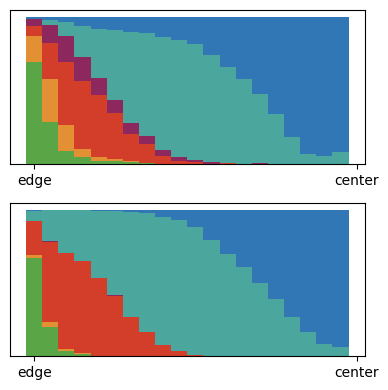

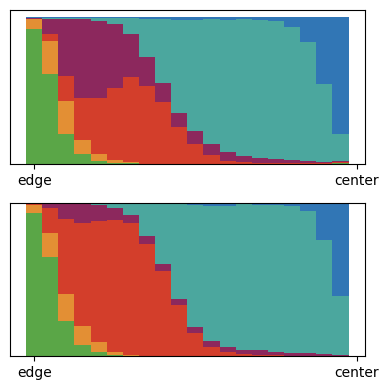

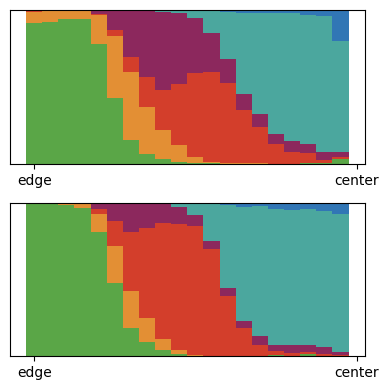

In [4]:
fig_size = [4,4]   
params = {
          'figure.figsize': fig_size,
          }
plt.rcParams.update(params)
H,W = 2,1


colors = fns_plot.return_colmaps('fates')
#widths = bins_x[1:]-bins_x[:-1]


for it_cond,cond in enumerate(conditions):
    
    subdirectory_plot = directory + '/analysis_regression_sg_multi_z1_3x10/analysis_crosscond_train_B50_pred_' + cond
    
    
    plt.figure()
    chrt=0
    for mode_sim in [1,0]:
        chrt+=1
        plt.subplot(H,W,chrt)

        for b_x in range(0,N_bins_x):
            for m in range(N_fates):
                
                if m>0:
                    bottom = sum(count_x_norm[it_cond,b_x,:m,mode_sim])
                else:
                    bottom = 0
                    
                plt.bar(b_x,height=count_x_norm[it_cond,b_x,m,mode_sim],bottom=bottom,width=1,color=colors[m],lw=2) #,width=widths[b_x]
            
        plt.xticks([0,N_bins_x],labels=['edge','center'])
        plt.yticks([])
        
    plt.tight_layout()
    plt.savefig(subdirectory_plot_fig + "/" + 'fig3_fates_dist_all_' + mode_reg + kernel + '_' + cond + file_suffix_pdf)
    

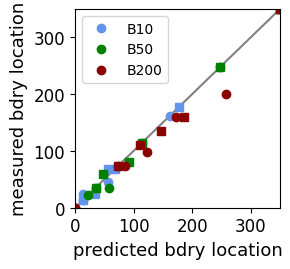

In [17]:
fig_size = [3,2.8]   
params = {
          'figure.figsize': fig_size,
          }
plt.rcParams.update(params)

plt.figure()
plt.plot([0,350],[0,350],'-',color='grey')
for it_cond,cond in enumerate(conditions):
    
    color=fns_plot.return_colmaps('conditions')[it_cond]
    
    boundaries = boundaries_all[it_cond,:,:,:]

    plt.plot(boundaries[0,:,1],boundaries[0,:,0],'o',color=color,label=cond)
    plt.plot(boundaries[1,:,1],boundaries[1,:,0],'s',color=color)
    
plt.xlim([0,350]) 
plt.ylim([0,350]) 
fs = 12;
plt.xticks([0,100,200,300],fontsize=fs) 
plt.yticks([0,100,200,300],fontsize=fs) 

plt.legend()

plt.xlabel('predicted bdry location', fontsize=fs+1)
plt.ylabel('measured bdry location', fontsize=fs+1)
    
plt.tight_layout()
plt.savefig(subdirectory_plot_fig + "/" + 'fig3_fates_boundaries_allcond_' + mode_reg + kernel + '_' + cond + file_suffix_pdf)